The **termination probability curve** tracks how often a recall stream stops after each output slot. We tally the first padding symbol per trial and compare its location across conditions. Switching the analysis `mode` to `'simple'` reports raw stop counts, while `'conditional'` divides by how often each slot is reached to highlight termination hazards.

In [1]:
import matplotlib.pyplot as plt
import os
import warnings

from jaxcmr.analyses.termination_probability import (
    plot_termination_probability,
    subject_output_length_mean,
    subject_output_length_median,
    test_output_length_mean_vs_control,
    test_output_length_median_vs_control,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset

warnings.filterwarnings("ignore")

def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


In [2]:
run_tag = "Termination"
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
mixed_trial_query = "data['list_type'] == 4"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 10
mode = "conditional"
ci_mode = "hierarchical"
n_resamples = 1000


In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)

control_dataset = make_control_dataset(
    data,
    mixed_trial_query,
    control_trial_query,
    control_shuffles,
)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)

datasets = [data, control_dataset]
masks = [trial_mask, control_mask]


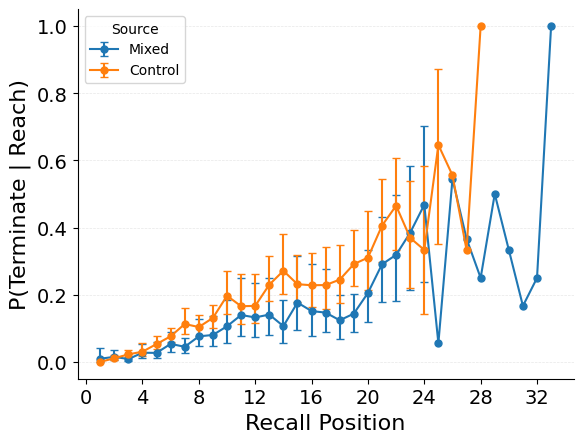

In [4]:
plot_termination_probability(
    datasets=datasets,
    trial_masks=masks,
    mode=mode,
    labels=["Mixed", "Control"],
    contrast_name="Source",
);
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)


In [7]:
observed_means = subject_output_length_mean(data, trial_mask)
control_means = subject_output_length_mean(control_dataset, control_mask)

mean_result = test_output_length_mean_vs_control(observed_means, control_means)

print()
print("=" * 70)
print("Output Length Test (Mean)")
print("=" * 70)
print("H0: Mean output length is the same in observed and control data.")
print(mean_result)

observed_medians = subject_output_length_median(data, trial_mask)
control_medians = subject_output_length_median(control_dataset, control_mask)

median_result = test_output_length_median_vs_control(observed_medians, control_medians)

print()
print("=" * 70)
print("Output Length Test (Median)")
print("=" * 70)
print("H0: Median output length is the same in observed and control data.")
print(median_result)



Output Length Test (Mean)
H0: Mean output length is the same in observed and control data.
N=35
Mean (observed): 13.6381
Mean (control): 13.3552
Mean difference: 0.2829
t-stat: 0.973 p=0.3375
W-stat: 253.5 p=0.3138

Output Length Test (Median)
H0: Median output length is the same in observed and control data.
N=35
Mean (observed): 13.8143
Mean (control): 13.1857
Mean difference: 0.6286
t-stat: 1.752 p=0.0888
W-stat: 120.5 p=0.0595
